# Special Token Experiment — 3 Personas Summary Results

Compares baseline (no tokens) vs trained special tokens across 3 personas.

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

import os
os.chdir("/users/eleves-a/2023/allegra-maria-pia.boustany/llm-wm")

## 1. Load Results

In [5]:
# update if needed when reorganising the repo (migrate experiments to special-token folder)
BASELINE_PATH = "llm-vs-llm/data/special-token/baseline_results.json"

# Single conversation results (result.json from each persona's single-conv run)
SINGLE_CONV_PATHS = {
    "bp_career_builder__st_formal": "llm-vs-llm/data/special-token/bp_career_builder__st_formal_single_sweep/token_count_sweep.json",
    "bp_tech_starter__st_formal": "llm-vs-llm/data/special-token/bp_tech_starter__st_formal_single_sweep/token_count_sweep.json",
    "bp_traveler__st_skeptical": "llm-vs-llm/data/special-token/bp_traveler__st_skeptical_single_sweep/token_count_sweep.json",
}

# Multi conversation sweep results
MULTI_CONV_PATHS = {
    "bp_career_builder__st_formal": "llm-vs-llm/data/special-token/bp_career_builder__st_formal_multi_sweep/num_conversations_sweep.json",
    "bp_tech_starter__st_formal": "llm-vs-llm/data/special-token/bp_tech_starter__st_formal_multi_sweep/num_conversations_sweep.json",
    "bp_traveler__st_skeptical": "llm-vs-llm/data/special-token/bp_traveler__st_skeptical_multi_sweep/num_conversations_sweep.json",
}

In [6]:
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

# Load baseline
baseline = load_json(BASELINE_PATH)
print("Baseline (no tokens):")
for k, v in baseline.items():
    print(f"  {k}: {v}")

Baseline (no tokens):
  bp_career_builder__st_formal: 2.3248
  bp_tech_starter__st_formal: 2.1844
  bp_traveler__st_skeptical: 2.3033


In [11]:
# Load single conv results
single_results = {}

# Career builder: from token count sweep (token_count=10)
try:
    sweep = load_json("llm-vs-llm/data/special-token/bp_career_builder__st_formal_single_sweep/token_count_sweep.json")
    for r in sweep:
        if r["config"]["token_count"] == 10:
            single_results["bp_career_builder__st_formal"] = r["final_eval_loss"]
            break
except FileNotFoundError:
    print("WARNING: career_builder token sweep not found")

# Tech starter: from single result.json
try:
    result = load_json("llm-vs-llm/data/special-token/bp_tech_starter__st_formal_single/result.json")
    single_results["bp_tech_starter__st_formal"] = result["final_eval_loss"]
except FileNotFoundError:
    print("WARNING: tech_starter single result not found")

# Traveler: from single result.json
try:
    result = load_json("llm-vs-llm/data/special-token/bp_traveler__st_skeptical_single/result.json")
    single_results["bp_traveler__st_skeptical"] = result["final_eval_loss"]
except FileNotFoundError:
    print("WARNING: traveler single result not found")

print("\nSingle-conv trained:")
for k, v in single_results.items():
    print(f"  {k}: {v:.4f}")


Single-conv trained:
  bp_career_builder__st_formal: 2.2129
  bp_tech_starter__st_formal: 2.1003
  bp_traveler__st_skeptical: 2.1919


In [12]:
# Load multi conv sweep results
multi_sweep_data = {}
multi_best = {}

for persona, path in MULTI_CONV_PATHS.items():
    try:
        sweep = load_json(path)
        multi_sweep_data[persona] = sweep
        # Find best
        best = min(sweep, key=lambda r: r["final_eval_loss"])
        multi_best[persona] = {
            "loss": best["final_eval_loss"],
            "num_conversations": best["config"]["num_train_conversations"]
        }
    except FileNotFoundError:
        print(f"WARNING: {path} not found")

print("\nBest multi-conv trained:")
for k, v in multi_best.items():
    print(f"  {k}: {v['loss']:.4f} ({v['num_conversations']} conversations)")


Best multi-conv trained:
  bp_career_builder__st_formal: 2.1702 (6 conversations)
  bp_tech_starter__st_formal: 2.0396 (8 conversations)
  bp_traveler__st_skeptical: 2.1460 (8 conversations)


## 2. Summary Table

In [13]:
personas = sorted(set(baseline.keys()) & set(single_results.keys()) & set(multi_best.keys()))

print("Baseline personas:", list(baseline.keys()))
print("Single conv personas:", list(single_results.keys()))
print("Multi best personas:", list(multi_best.keys()))

rows = []
for p in personas:
    b = baseline[p]
    s = single_results[p]
    m = multi_best[p]
    rows.append({
        "Persona": p.replace("bp_", "").replace("__st_", " / "),
        "Baseline (no tokens)": round(b, 4),
        "Trained (1 conv)": round(s, 4),
        "Δ (1 conv)": round(s - b, 4),
        "Trained (best multi)": round(m["loss"], 4),
        "N conv": m["num_conversations"],
        "Δ (best multi)": round(m["loss"] - b, 4),
    })

# Add mean row
rows.append({
    "Persona": "MEAN",
    "Baseline (no tokens)": round(np.mean([r["Baseline (no tokens)"] for r in rows]), 4),
    "Trained (1 conv)": round(np.mean([r["Trained (1 conv)"] for r in rows]), 4),
    "Δ (1 conv)": round(np.mean([r["Δ (1 conv)"] for r in rows]), 4),
    "Trained (best multi)": round(np.mean([r["Trained (best multi)"] for r in rows]), 4),
    "N conv": "-",
    "Δ (best multi)": round(np.mean([r["Δ (best multi)"] for r in rows]), 4),
})

df = pd.DataFrame(rows)
df

Baseline personas: ['bp_career_builder__st_formal', 'bp_tech_starter__st_formal', 'bp_traveler__st_skeptical']
Single conv personas: ['bp_career_builder__st_formal', 'bp_tech_starter__st_formal', 'bp_traveler__st_skeptical']
Multi best personas: ['bp_career_builder__st_formal', 'bp_tech_starter__st_formal', 'bp_traveler__st_skeptical']


,Persona,Baseline (no tokens),Trained (1 conv),Δ (1 conv),Trained (best multi),N conv,Δ (best multi)
0,career_builder / formal,2.3248,2.2129,-0.1119,2.1702,6,-0.1546
1,tech_starter / formal,2.1844,2.1003,-0.0841,2.0396,8,-0.1448
2,traveler / skeptical,2.3033,2.1919,-0.1114,2.1460,8,-0.1573
3,MEAN,2.2708,2.1684,-0.1025,2.1186,-,-0.1522


## 3. Bar Chart: Baseline vs Trained

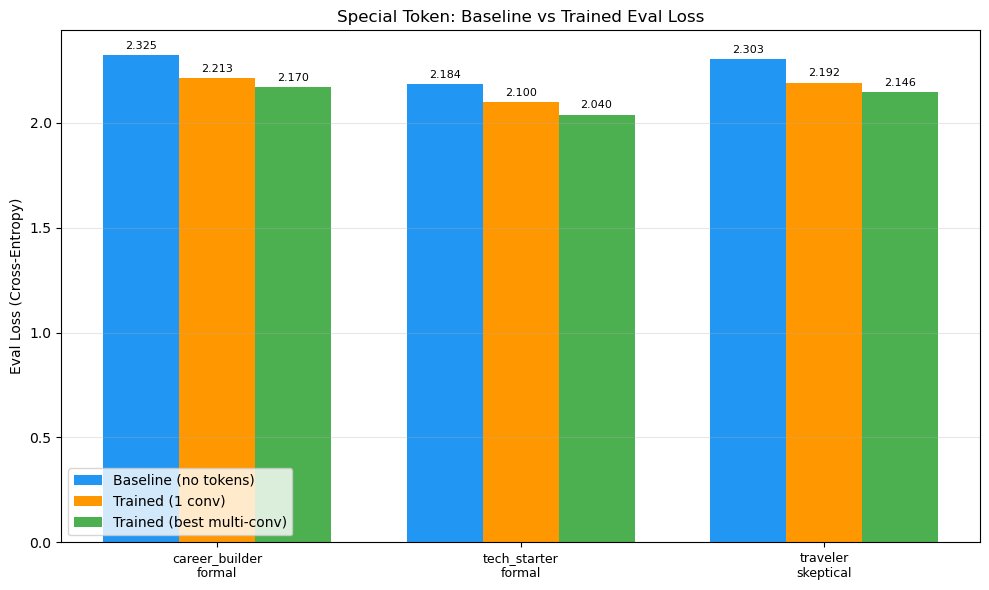

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(personas))
width = 0.25

baselines = [baseline[p] for p in personas]
singles = [single_results[p] for p in personas]
multis = [multi_best[p]["loss"] for p in personas]

bars1 = ax.bar(x - width, baselines, width, label="Baseline (no tokens)", color="#2196F3")
bars2 = ax.bar(x, singles, width, label="Trained (1 conv)", color="#FF9800")
bars3 = ax.bar(x + width, multis, width, label="Trained (best multi-conv)", color="#4CAF50")

ax.set_ylabel("Eval Loss (Cross-Entropy)")
ax.set_title("Special Token: Baseline vs Trained Eval Loss")
ax.set_xticks(x)
short_names = [p.replace("bp_", "").replace("__st_", "\n") for p in personas]
ax.set_xticklabels(short_names, fontsize=9)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("baseline_vs_trained.png", dpi=300)
plt.show()

## 4. Conversation Count Sweep (All Personas)

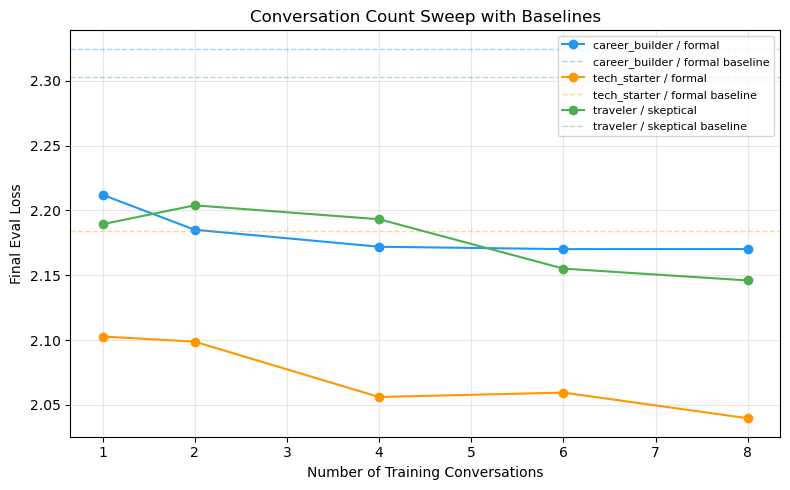

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2196F3", "#FF9800", "#4CAF50"]

for i, persona in enumerate(personas):
    if persona in multi_sweep_data:
        sweep = multi_sweep_data[persona]
        xs = [r["config"]["num_train_conversations"] for r in sweep]
        ys = [r["final_eval_loss"] for r in sweep]
        short_name = persona.replace("bp_", "").replace("__st_", " / ")
        ax.plot(xs, ys, marker="o", label=short_name, color=colors[i])
        
        # Baseline as dashed line
        ax.axhline(y=baseline[persona], color=colors[i],
                   linestyle="--", alpha=0.4, linewidth=1,
                   label=f"{short_name} baseline")

ax.set_xlabel("Number of Training Conversations")
ax.set_ylabel("Final Eval Loss")
ax.set_title("Conversation Count Sweep with Baselines")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("conv_sweep_all_personas.png", dpi=300)
plt.show()

## 5. Delta Improvement from Baseline

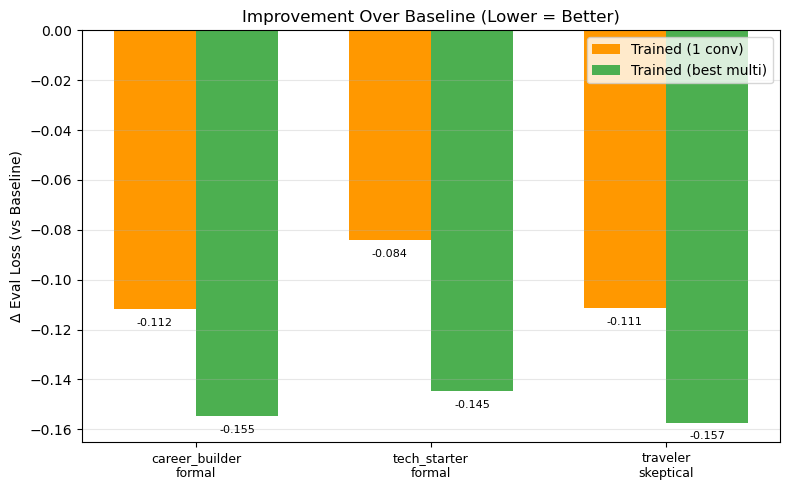

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(personas))
width = 0.35

delta_singles = [single_results[p] - baseline[p] for p in personas]
delta_multis = [multi_best[p]["loss"] - baseline[p] for p in personas]

ax.bar(x - width/2, delta_singles, width, label="Trained (1 conv)", color="#FF9800")
ax.bar(x + width/2, delta_multis, width, label="Trained (best multi)", color="#4CAF50")

ax.set_ylabel("Δ Eval Loss (vs Baseline)")
ax.set_title("Improvement Over Baseline (Lower = Better)")
ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=9)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.axhline(y=0, color="black", linewidth=0.5)

# Add value labels
for i, (ds, dm) in enumerate(zip(delta_singles, delta_multis)):
    ax.annotate(f'{ds:.3f}', xy=(i - width/2, ds), xytext=(0, -12),
                textcoords="offset points", ha='center', fontsize=8)
    ax.annotate(f'{dm:.3f}', xy=(i + width/2, dm), xytext=(0, -12),
                textcoords="offset points", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig("delta_improvement.png", dpi=300)
plt.show()

## 6. Summary Statistics

In [17]:
print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)
print(f"Mean baseline eval loss:           {np.mean(baselines):.4f}")
print(f"Mean trained (1 conv) eval loss:    {np.mean(singles):.4f}")
print(f"Mean trained (best multi):          {np.mean(multis):.4f}")
print(f"Mean Δ (1 conv vs baseline):        {np.mean(delta_singles):.4f}")
print(f"Mean Δ (best multi vs baseline):    {np.mean(delta_multis):.4f}")
print(f"Mean additional gain (multi vs 1):  {np.mean(delta_multis) - np.mean(delta_singles):.4f}")
print("=" * 60)

KEY FINDINGS
Mean baseline eval loss:           2.2708
Mean trained (1 conv) eval loss:    2.1684
Mean trained (best multi):          2.1186
Mean Δ (1 conv vs baseline):        -0.1025
Mean Δ (best multi vs baseline):    -0.1523
Mean additional gain (multi vs 1):  -0.0498
